# Motivation 

KNN is one of the simplest machine learning models, and we use it a lot in computational physics because it's so straightforward. In this notebook, I'm studying for the Prian Machine Learning course and I've also read an IBM post, which you can find below.

https://www.ibm.com/think/topics/knn

# K-Nearest Neighbors (KNN)

## What is KNN?
KNN is a **supervised learning** algorithm used for classification and regression.

### How it works:
1. Choose a value of **K** (number of neighbors)
2. Calculate the **distance** between the new point and all training points (I never imagined there were so many ways to measure distances besides Euclidean ones for this case)
3. Select the **K nearest neighbors**
4. For classification: **majority vote** among the K neighbors
5. For regression: **mean** of the K neighbors' values

### Pros and Cons:
| Pros | Cons |
|------|------|
| Simple to understand | Slow on large datasets |
| No assumptions about data distribution | Sensitive to features at different scales |
| Works well with small data | Need to choose appropriate K |

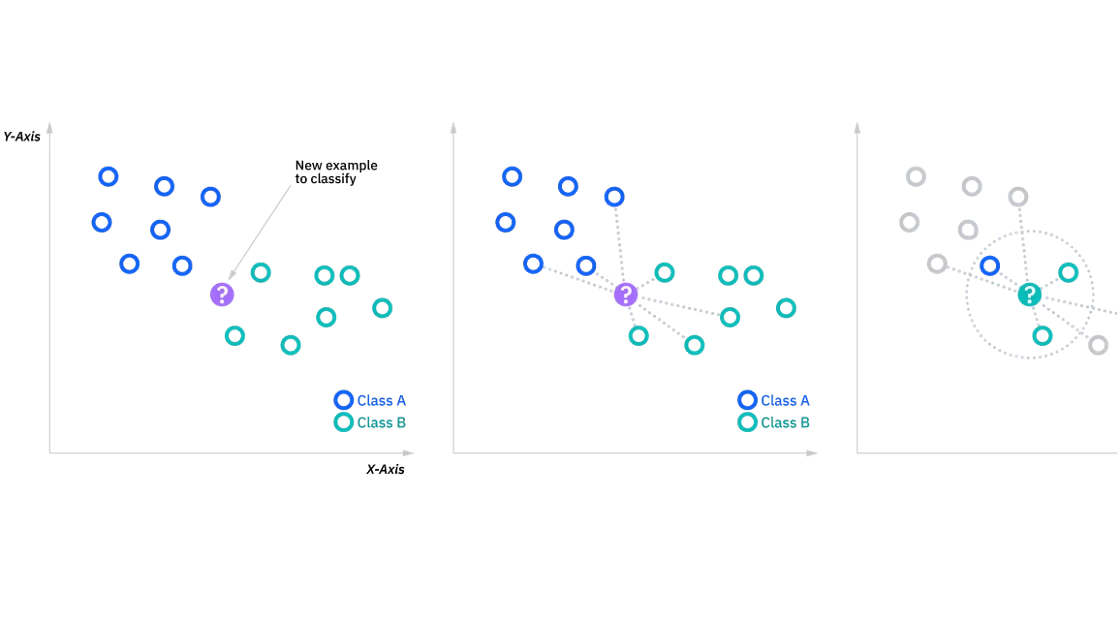

## 1. Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [2]:
# Load data (example with Iris dataset)
from sklearn.datasets import load_iris
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Data Preparation

### Why normalize?
KNN uses **distance** to find neighbors. If one feature has much larger values than others, it will dominate the distance calculation.

**Example:** If we have height (1.5-2.0m) and salary (1000-10000), salary will dominate!

In [3]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 120 samples
Test: 30 samples


## 3. Basic KNN (without Pipeline)

In [4]:
# Scale the data first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 4. Using Pipeline + GridSearchCV

Pipeline avoids data leakage by applying scaler inside cross-validation. GridSearchCV tests multiple K values and picks the best one.

In [5]:
# Create pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Test K from 1 to 20
param_grid = {'knn__n_neighbors': list(range(1, 21))}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Best K: {grid.best_params_['knn__n_neighbors']}")
print(f"Best CV score: {grid.best_score_:.3f}")

Best K: 3
Best CV score: 0.950


## 5. Elbow Method

Plotting accuracy vs K helps visualize the best choice.

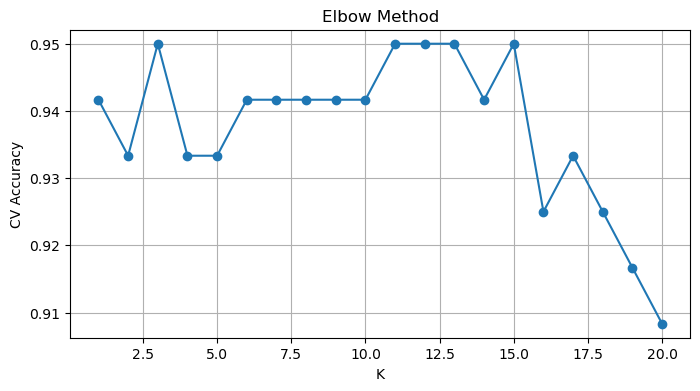

In [6]:
k_values = list(range(1, 21))
cv_scores = grid.cv_results_['mean_test_score']

plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

## 6. Final Evaluation

In [7]:
# Use best model from GridSearch
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



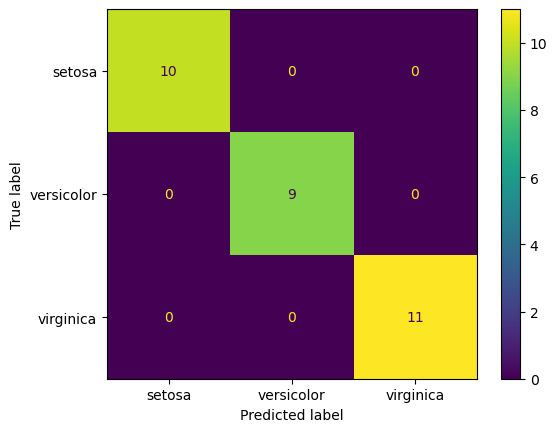

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()
plt.show()